In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   -- ------------------------------------- 1.3/24.4 MB 8.4 MB/s eta 0:00:03
   ------ --------------------------------- 3.7/24.4 MB 9.9 MB/s eta 0:00:03
   --------- ------------------------------ 6.0/24.4 MB 10.5 MB/s eta 0:00:02
   ------------ --------------------------- 7.3/24.4 MB 10.3 MB/s eta 0:00:02
   --------------- ------------------------ 9.4/24.4 MB 9.6 MB/s eta 0:00:02
   ------------------- -------------------- 12.1/24.4 MB 10.1 MB/s eta 0:00:02
   ------------------------ --------------- 14.7/24.4 MB 10.5 MB/s eta 0:00:01
   --------------------------- ------------ 16.8/24.4 MB 10.5 MB/s eta 0:00:01
   ------------------------------- -------- 19.4/24.4 MB 10.6 MB/s eta 0:00:01
   ----------------------------------- ---- 21.8/24.4 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 10.5 MB/s  0


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\fredd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import gensim.downloader as api

# cargar modelo
model = api.load("word2vec-google-news-300") # 0 word2vec-google-news-300

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [7]:
model

In [8]:
vec = lambda word: model[word]

In [9]:
model ["dog"]

array([ 5.12695312e-02, -2.23388672e-02, -1.72851562e-01,  1.61132812e-01,
       -8.44726562e-02,  5.73730469e-02,  5.85937500e-02, -8.25195312e-02,
       -1.53808594e-02, -6.34765625e-02,  1.79687500e-01, -4.23828125e-01,
       -2.25830078e-02, -1.66015625e-01, -2.51464844e-02,  1.07421875e-01,
       -1.99218750e-01,  1.59179688e-01, -1.87500000e-01, -1.20117188e-01,
        1.55273438e-01, -9.91210938e-02,  1.42578125e-01, -1.64062500e-01,
       -8.93554688e-02,  2.00195312e-01, -1.49414062e-01,  3.20312500e-01,
        3.28125000e-01,  2.44140625e-02, -9.71679688e-02, -8.20312500e-02,
       -3.63769531e-02, -8.59375000e-02, -9.86328125e-02,  7.78198242e-03,
       -1.34277344e-02,  5.27343750e-02,  1.48437500e-01,  3.33984375e-01,
        1.66015625e-02, -2.12890625e-01, -1.50756836e-02,  5.24902344e-02,
       -1.07421875e-01, -8.88671875e-02,  2.49023438e-01, -7.03125000e-02,
       -1.59912109e-02,  7.56835938e-02, -7.03125000e-02,  1.19140625e-01,
        2.29492188e-01,  

In [10]:
vec("word")

array([ 3.59375000e-01,  4.15039062e-02,  9.03320312e-02,  5.46875000e-02,
       -1.47460938e-01,  4.76074219e-02, -8.49609375e-02, -2.04101562e-01,
        3.10546875e-01, -1.05590820e-02, -6.15234375e-02, -1.55273438e-01,
       -1.52343750e-01,  8.54492188e-02, -2.70996094e-02,  3.84765625e-01,
        4.78515625e-02,  2.58789062e-02,  4.49218750e-02, -2.79296875e-01,
        9.09423828e-03,  4.08203125e-01,  2.40234375e-01, -3.06640625e-01,
       -1.80664062e-01,  4.73632812e-02, -2.63671875e-01,  9.08203125e-02,
        1.37695312e-01, -7.20977783e-04,  2.67333984e-02,  1.92382812e-01,
       -2.29492188e-02,  9.70458984e-03, -7.37304688e-02,  4.29687500e-01,
       -7.93457031e-03,  1.06445312e-01,  2.80761719e-02, -2.29492188e-01,
       -1.91650391e-02, -2.36816406e-02,  3.51562500e-02,  1.71875000e-01,
       -1.12304688e-01,  6.25000000e-02, -1.69921875e-01,  1.29882812e-01,
       -1.54296875e-01,  1.58203125e-01, -7.76367188e-02,  1.78710938e-01,
       -1.72851562e-01,  

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
cosine_similarity([vec("teacher")], [vec("student")])

array([[0.63013655]], dtype=float32)

In [14]:
cosine_similarity([vec("king")], [vec("queen")])

array([[0.6510957]], dtype=float32)

In [15]:
# analogías De Hombre es a Mujer como Rey es a ?   
vec_man = vec("man")
vec_woman = vec("woman")
dist = vec_woman - vec_man

In [ ]:
# Ahora sumamos esta distancia al vector de "king" para encontrar el vector resultante
vec_king = vec("king")
x = vec_king + dist

In [ ]:
# Finalmente, calculamos la similitud entre el vector resultante y el vector de "queen" para ver qué tan cerca están
cosine_similarity([x], [vec("queen")])

array([[0.7300518]], dtype=float32)

In [ ]:
# Lo que hace most_similar es encontrar los vectores más cercanos al vector dado, en este caso el vector resultante de la analogía
model.most_similar(x)

[('king', 0.8449392318725586),
 ('queen', 0.7300517559051514),
 ('monarch', 0.645466148853302),
 ('princess', 0.6156251430511475),
 ('crown_prince', 0.5818676352500916),
 ('prince', 0.5777117609977722),
 ('kings', 0.5613663792610168),
 ('sultan', 0.5376775860786438),
 ('Queen_Consort', 0.5344247817993164),
 ('queens', 0.5289887189865112)]

In [30]:
# Para ahora dibujar un vector, que hace n_components=2, es decir, que queremos reducir la dimensionalidad de 300 dimensiones a 2 dimensiones para poder graficar
from sklearn.decomposition import PCA
pca = PCA(n_components=2)


In [31]:
v = pca.fit_transform([vec_man, vec_woman, vec_king, vec("queen"), x])

Text(-1.3917118426935577, -0.06604009421471199, 'x')

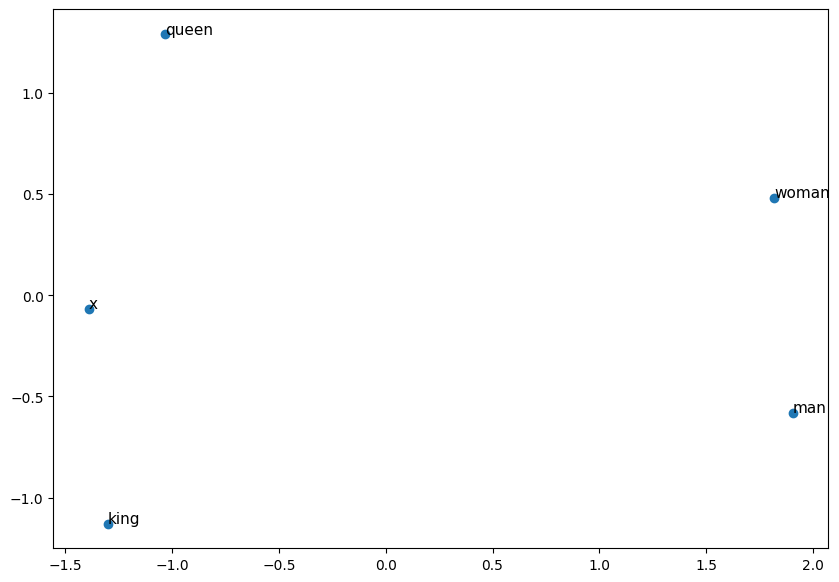

In [32]:
plt.figure(figsize=(10, 7))
plt.scatter(v[:, 0], v[:, 1])

plt.annotate('man', (v[0, 0], v[0, 1]), fontsize=11)
plt.annotate('woman', (v[1, 0], v[1, 1]), fontsize=11)
plt.annotate('king', (v[2, 0], v[2, 1]), fontsize=11)
plt.annotate('queen', (v[3, 0], v[3, 1]), fontsize=11)
plt.annotate('x', (v[4, 0], v[4, 1]), fontsize=11)

In [ ]:
p =  ['madrid', 'spain', 'paris', 'france']
v300 = [vec(word) for word in p]

x = (vec('spain') - vec('madrid')) + vec('paris')
v300.append(x)

plt 

<module 'matplotlib.pyplot' from 'C:\\Users\\fredd\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

Text(-2.813456770141054, -0.21528911698751843, 'x')

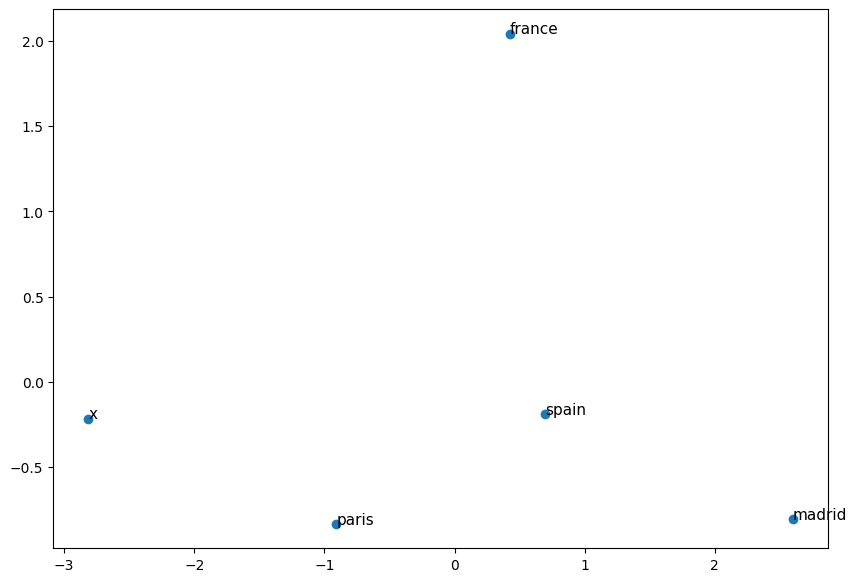

In [34]:
v = pca.fit_transform(v300)

plt.figure(figsize=(10, 7))
plt.scatter(v[:, 0], v[:, 1])

plt.annotate('madrid', (v[0, 0], v[0, 1]), fontsize=11)
plt.annotate('spain', (v[1, 0], v[1, 1]), fontsize=11)
plt.annotate('paris', (v[2, 0], v[2, 1]), fontsize=11)
plt.annotate('france', (v[3, 0], v[3, 1]), fontsize=11)
plt.annotate('x', (v[4, 0], v[4, 1]), fontsize=11)